In [23]:

import pandas as pd
import geopandas as gps
import pli_uso_pro as pup 
import numpy as np 
from pathlib import Path
import matplotlib.pyplot as plt 
import matplotlib as mpl
import seaborn as sns
import scipy as sc



In [24]:
# visualisação das pastas dentro da planilha de dados 
planilha = pd.ExcelFile("dados.xlsx").sheet_names
planilha

['HS',
 'BD',
 'CADASTRO MOTORISTA',
 'SETORES POR DIA',
 'MOVIMENTO',
 'Resumo Diário',
 'ACESSO',
 'Ton-VG-Dia',
 'Planilha1',
 'Dados_gráficos ',
 'Tempo',
 'Tempo_média',
 'KM',
 'KM_média',
 'Ton',
 'Ton_média',
 'Ton_hora_média',
 'ton_KM_média']

In [25]:
# importação da base de dados e conversão das colunas para formato datetime
df = pd.read_excel("dados.xlsx", sheet_name = "Dados_gráficos ")
lista = ["Tempo_Coleta", "Tempo_Trajeto", "Tempo_Aterro"]
lista_var_time = ["t_coleta_n", "t_trajeto_n", "t_aterro_n"]
for i in range(0,len(lista)): 
    df[lista[i]] = pd.to_datetime(df[lista[i]], format = "%H:%M:%S", errors = "coerce")
    df[lista_var_time[i]] = df[lista[i]].dt.hour + df[lista[i]].dt.minute/60 + df[lista[i]].dt.second/3600


In [26]:
# colunas contidas dentro da base de dados 
df.columns

Index(['Data', 'Mês ', 'Dia_mês', 'Dia_semana', 'Setor', 'Turno', 'Carro',
       'Tempo_Coleta', 'Horas_coleta', 'Tempo_Trajeto', 'Tempo_Aterro',
       'KM _COLETA', 'KM_TRAJETO', 'PRODUÇÃO', 'Produção_ton', 'Viagens ',
       'Ton/Horas', 'Ton/KM', 't_coleta_n', 't_trajeto_n', 't_aterro_n'],
      dtype='object')

In [46]:
# readequação da base de dados horiginal
# junção das observações por dia e setor 
# inclusão de indicadores de interesse 

analise = df.groupby(["Data", "Dia_semana", "Setor", "Turno"]).agg(km_coleta = ("KM _COLETA", "sum"),
                                                                         km_trajeto = ("KM_TRAJETO", "sum"),
                                                                         viagens = ("Viagens ", "sum"),
                                                                         t_coleta = ("t_coleta_n", "sum"),
                                                                         t_trajeto = ("t_trajeto_n", "sum"),
                                                                         t_aterro = ("t_aterro_n", "sum"),
                                                                         ton = ("Produção_ton", "sum"),
                                                                         ton_hora = ("Ton/Horas", "mean"))

analise.reset_index(inplace = True)

analise["ton_km"] = analise["ton"]/analise["km_coleta"]
analise["t_total"] = analise["t_coleta"] + analise["t_trajeto"] + analise["t_aterro"]
analise["km_por_desloc"] = analise["km_trajeto"]/analise["viagens"]
analise["km_por_hora_desl"] = analise["km_trajeto"]/(analise["t_trajeto"])
analise["tempo_aterro"] = analise["t_aterro"]/analise["viagens"]
analise["horas_extras"] = analise["t_total"] - 8.333
analise["km_total"] = analise["km_coleta"] + analise["km_trajeto"]
analise = analise[(analise["Setor"] != 22) & (analise["Setor"] != 23)]
analise.reset_index(inplace = True, drop = True)




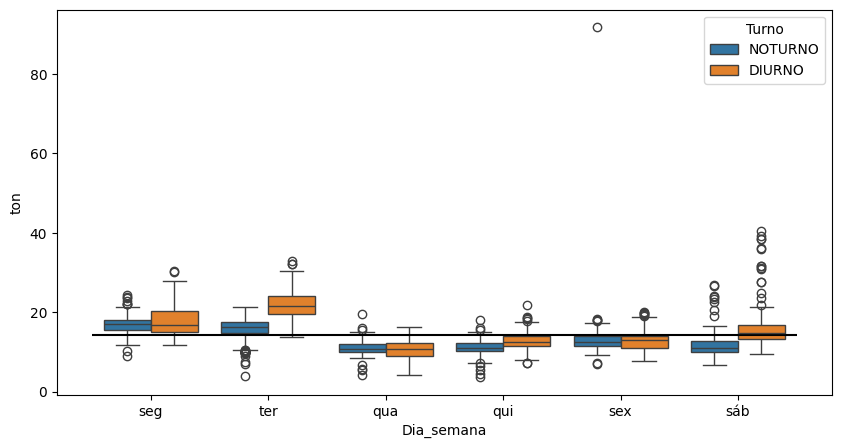

In [47]:
# análise prévia da tonelagem , agrupando por dia da semana e turno, para identificar os dias e turnos mais pesados 

figura, axis = plt.subplots(figsize = (10,5))
ordem = ["seg", "ter", "qua", "qui", "sex", "sáb"]
sns.boxplot(data = analise, x = "Dia_semana", y = "ton", ax = axis, legend= "full",hue = "Turno", order = ordem)
axis.hlines(xmin = -0.5, xmax = 5.5, y = analise["ton"].mean(), color = "black")

In [48]:
# ajuste do outlier identificado 
dropar = analise[analise["ton"] == analise["ton"].max()].index
analise.loc[2516, "ton"] = 9.178

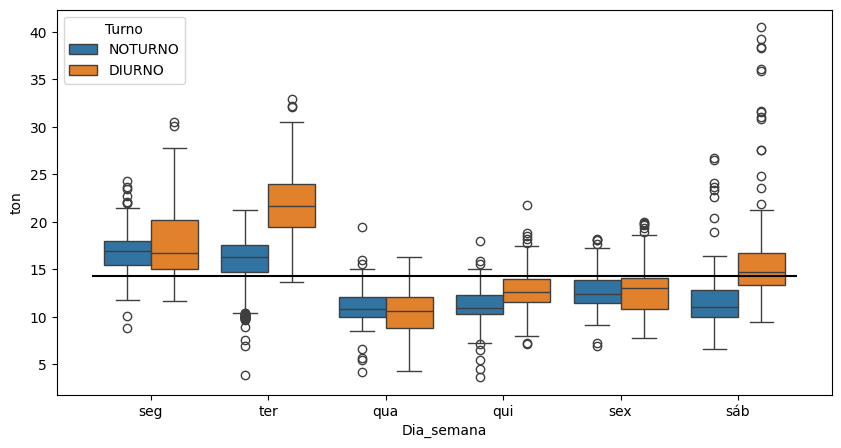

In [49]:
#verificação 
igura, axis = plt.subplots(figsize = (10,5))
ordem = ["seg", "ter", "qua", "qui", "sex", "sáb"]
sns.boxplot(data = analise, x = "Dia_semana", y = "ton", ax = axis, legend= "full",hue = "Turno", order = ordem)
axis.hlines(xmin = -0.5, xmax = 5.5, y = analise["ton"].mean(), color = "black")

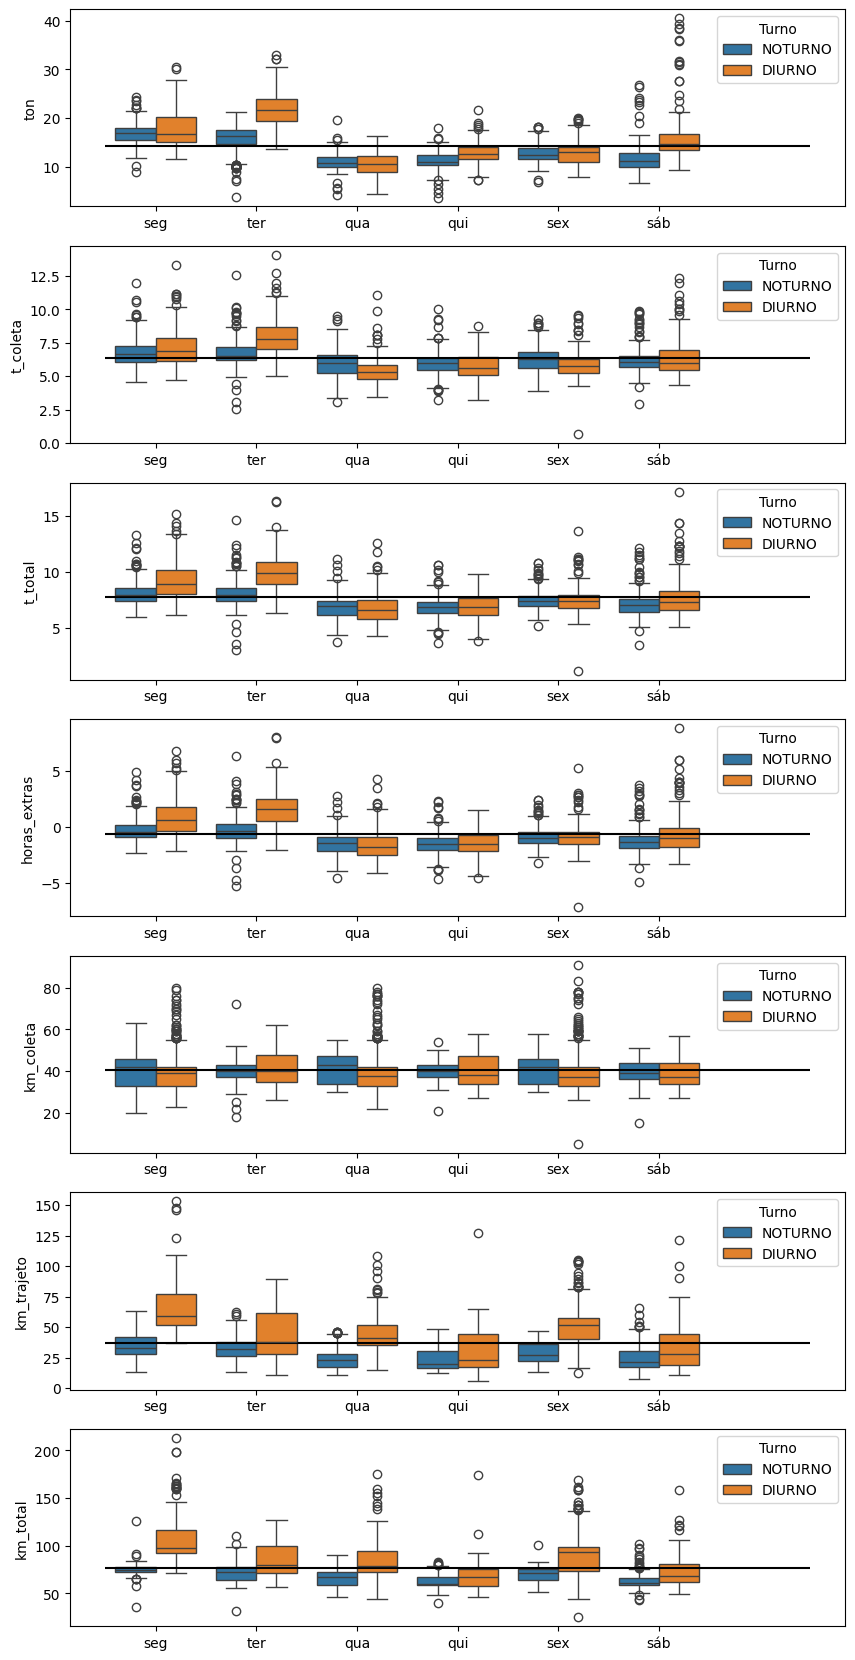

In [50]:
# visualisação das variáveis de interesse segmentadas por dia da semana e por turno 
interesse = ["ton", "t_coleta", "t_total", "horas_extras", "km_coleta", "km_trajeto", "km_total"]
ordem = ["seg", "ter", "qua", "qui", "sex", "sáb"]

figura, axis = plt.subplots(len(interesse),1, figsize = (10,len(interesse)*3))

for i in range(0,len(interesse)):
    sns.boxplot(ax = axis[i], data = analise, x = "Dia_semana", y = interesse[i], hue = "Turno", order = ordem) 
    axis[i].hlines(xmin = -0.5, xmax = 6.5, y = analise[interesse[i]].mean(), color = "black")
    axis[i].set(xlabel = "")

In [51]:
# os dias que produzem mais toneladas e que gastam mais horas extras são segunda e terça feira
# os devem ser filtrados para analise detalhada dos setores que trabalham nesses dias 
dias_p = analise[(analise["Dia_semana"] == "seg") | (analise["Dia_semana"] == "ter")]
dias_p.reset_index(inplace = True, drop = True)


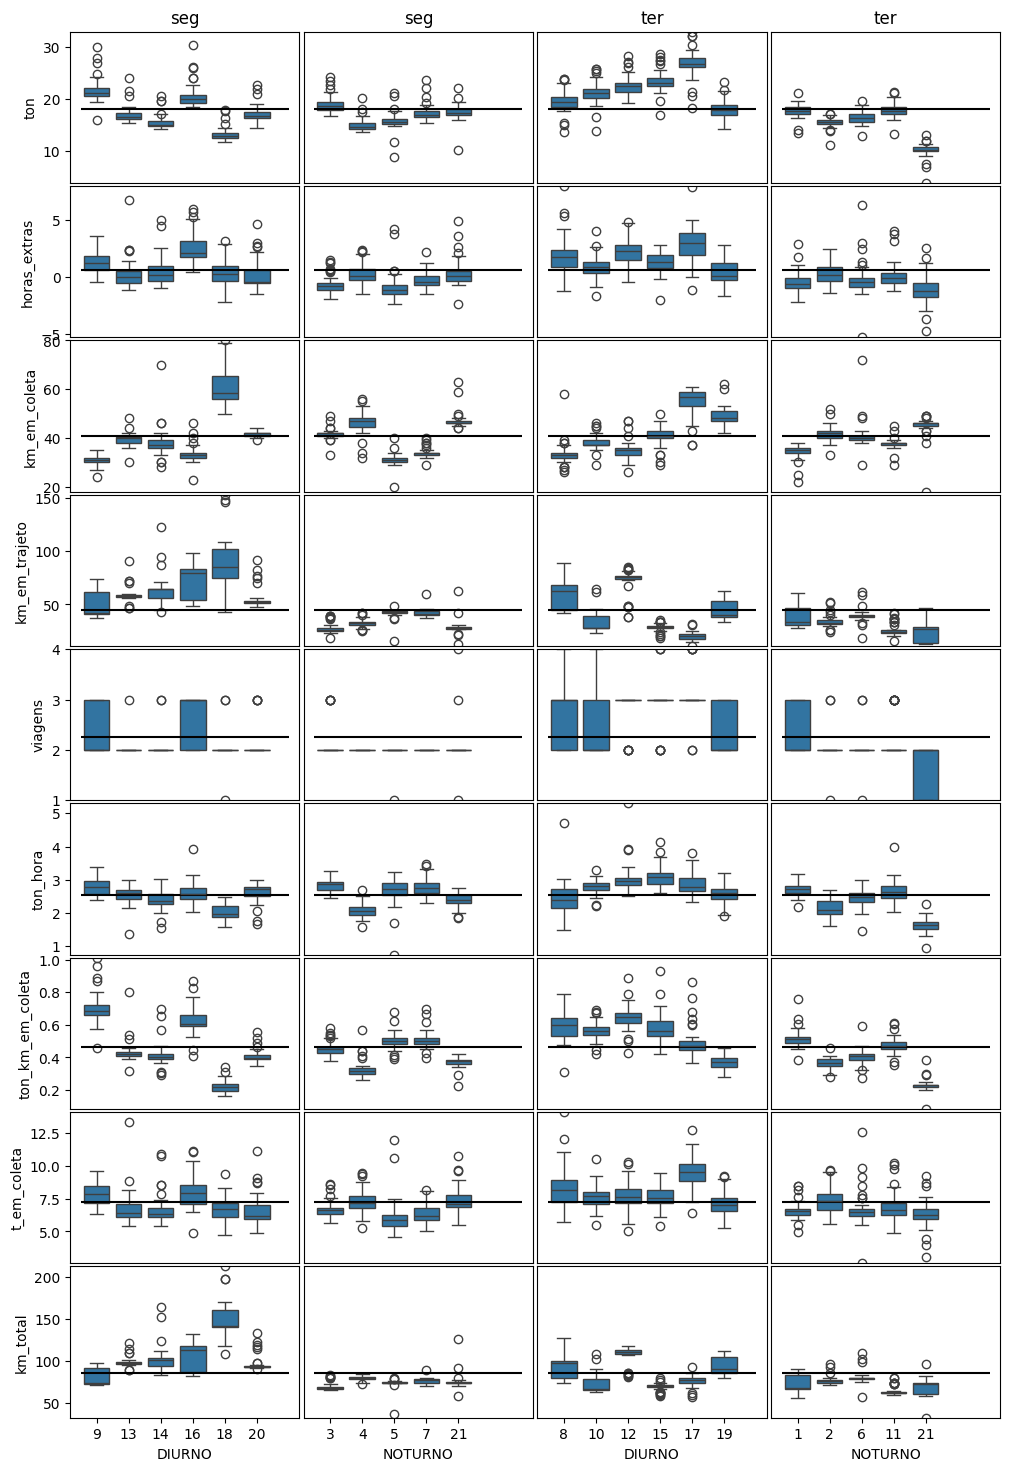

In [ ]:
# boxplot das variáveis de interesse, segmentadas por setor, para identificação de setores sobrecarregados 

interesse = ["ton", "horas_extras", "km_coleta", "km_trajeto", "viagens", "ton_hora", "ton_km", "t_coleta", "km_total"]

dia_semana = ["seg","seg","ter","ter"]
turno = ["DIURNO","NOTURNO","DIURNO","NOTURNO"]

figura, axis = plt.subplots(len(interesse), len(dia_semana), figsize = (len(dia_semana)*3, len(interesse)*2))
figura.subplots_adjust(wspace = 0.02, hspace = 0.02)

for i in range(0,len(interesse)):
    for j in range(0,len(dia_semana)):
        sns.boxplot(ax = axis[i,j], data = dias_p[(dias_p["Dia_semana"]== dia_semana[j]) & (dias_p["Turno"]== turno[j])], x = "Setor", y = interesse[i])
        min = dias_p[interesse[i]].min()
        max = dias_p[interesse[i]].max()
        media = dias_p[interesse[i]].mean()
        axis[i,j].set_ylim([min,max])
        axis[i,j].hlines(xmin = -0.5, xmax = 6, y = media, color = "black")

        if j !=0:
            axis[i,j].set(yticks = [])
            axis[i,j].set_ylabel("")
        if i == 0:
            axis[i,j].set_title(dia_semana[j])
        
        if i != len(interesse)-1:
            axis[i,j].set(xticks = [], xlabel = "")
        else:
            axis[i,j].set(xlabel = turno[j])

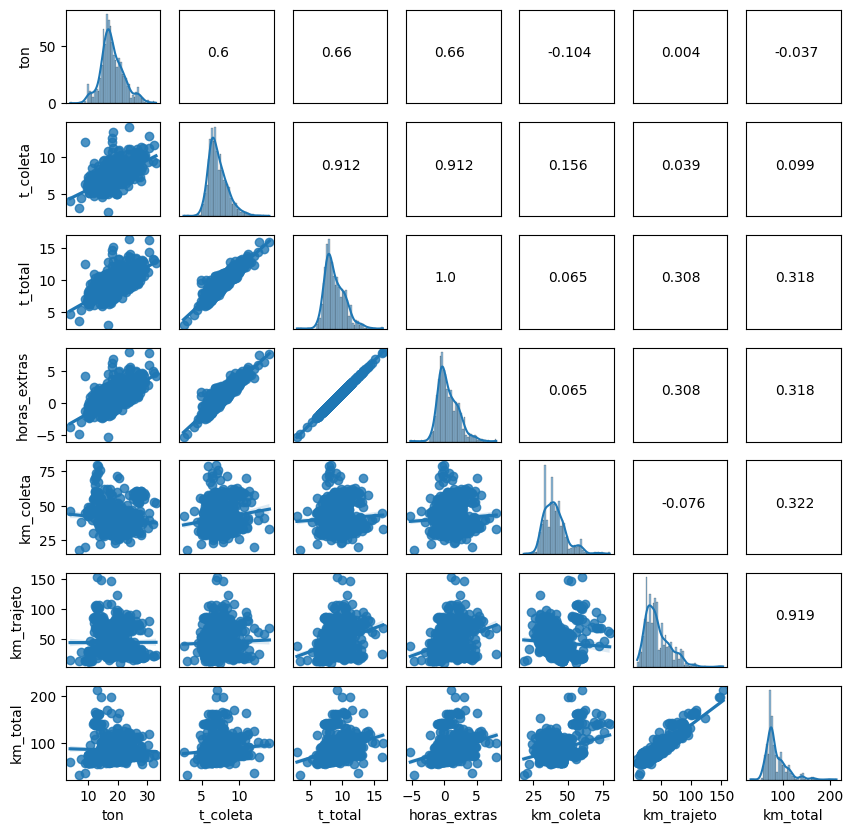

In [ ]:
# Matriz de correlação
# Objetivo: encontrar correlação importante entre a quatidade de horas extras, km em deslocamento e demais variáveis de interesse
pup.matriz_corr(dias_p, interesse, (10,10))

[Text(0.5, 1.0, 'Tonelagem_Estimada'), [], []]

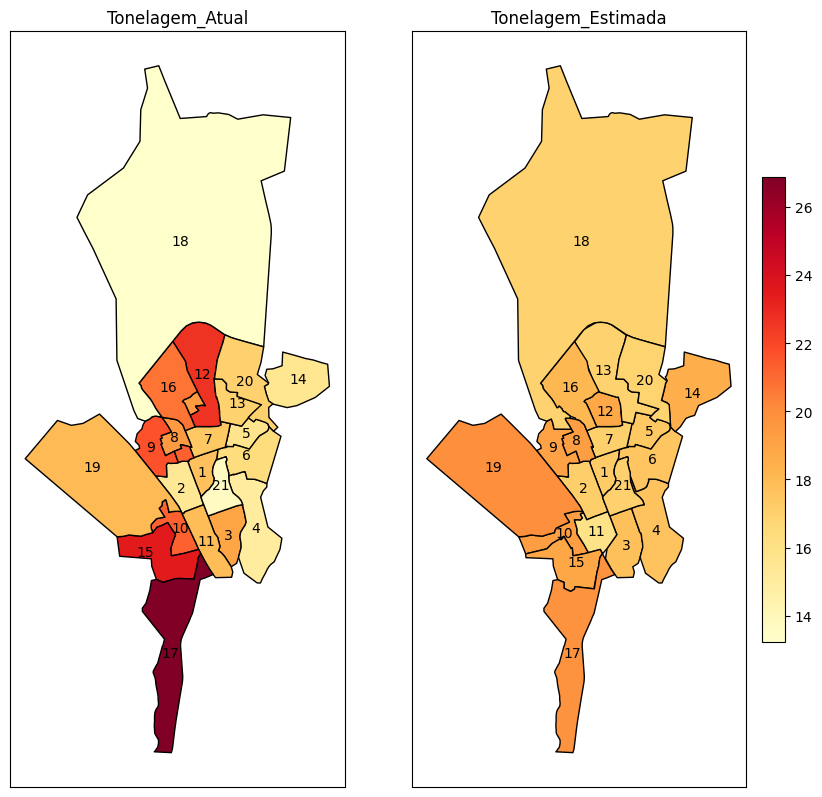

In [ ]:

# os mesmo também possuem a maior média de horas extras 
# enquanto os setores noturnos ficam abaixo da média de tonelagem e de horas extras
# Foi elaborado um remapeamento dos setores, visando redistribuir a tonelagem 
#  HEATMAP DOS SETORES PRÉ E PÓS READEQUAÇÃO, COM GRADIENTE DE COR POR TONELAGEM 

caminho = Path("C:\\Users\\felip\\OneDrive\\Documentos\\Projeto_mestrado\\Analise descritiva\\Sustentare_readequação\\arquivos georeferenciados\\Setores_atuais")
caminho1 = Path("C:\\Users\\felip\\OneDrive\\Documentos\\Projeto_mestrado\\Analise descritiva\\Sustentare_readequação\\arquivos georeferenciados\\Setores_readequação")
arquivo = caminho / "01.shp"
arquivo1 = caminho1 / "01C.shp"
mapa_atual = gps.read_file(arquivo)
mapa_read = gps.read_file(arquivo1)

for i in range(2,22):
    if i <10: 
        arquivo = caminho / f"0{i}.shp"
        arquivo1 = caminho1 / f"0{i}C.shp"
        mapa = gps.read_file(arquivo)
        mapa1 = gps.read_file(arquivo1)
        mapa_atual = pd.concat([mapa_atual, mapa])
        mapa_read = pd.concat([mapa_read, mapa1])
    else:
        arquivo = arquivo = caminho / f"{i}.shp"
        arquivo1 = caminho1 / f"{i}C.shp"
        mapa = gps.read_file(arquivo)
        mapa1 = gps.read_file(arquivo1)
        mapa_atual = pd.concat([mapa_atual, mapa])
        mapa_read = pd.concat([mapa_read, mapa1])


tonelagem = dias_p.groupby("Setor")["ton"].mean()
tonelagem1 = pd.read_excel("Proposta_setores_1.xlsx", sheet_name = "ton_prev")["ton"]

xminimo = tonelagem.min()
xmaximo = tonelagem.max()

mapa_atual["ton"] = tonelagem.values
mapa_read["ton"] = tonelagem1.values
figura, axis = plt.subplots(1,2, figsize = (10,10))
mapa_atual.plot(ax = axis[0], column = "ton", cmap = "YlOrRd", edgecolor= "black")
mapa_read.plot(ax = axis[1], column = "ton", cmap = "YlOrRd", edgecolor= "black", vmax = xmaximo, vmin= xminimo)

setores = range(1,22)
for i, valor in enumerate(mapa_atual["geometry"].representative_point()):
    axis[0].text(x = valor.x, y = valor.y, s = setores[i], ha = "center", va = "center")

for i, valor in enumerate(mapa_read["geometry"].representative_point()):
    axis[1].text(x = valor.x, y = valor.y, s = setores[i], ha = "center", va = "center")

norm = mpl.colors.Normalize(vmin=xminimo, vmax=xmaximo)
sm = mpl.cm.ScalarMappable(norm=norm, cmap="YlOrRd")
cbar = figura.colorbar(sm, ax=axis, fraction=0.03, pad=0.02)

axis[0].set(title = "Tonelagem_Atual", xticks = [], yticks = [])
axis[1].set(title = "Tonelagem_Estimada", xticks = [], yticks = [])

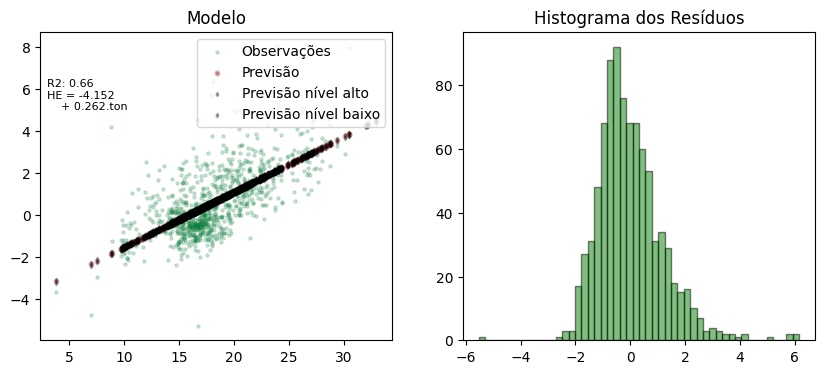

In [110]:
# a tonelagem encontrou correlação leve com a quantidade de horas extras (0.66), 
# apesar de não ser uma correlação forte, foi um dos melhores valores de correlação obtidos
# com a tonelagem atual e a tonelagem prevista para cada setor após a readequação, pode-se estimar a quantidade de horas extras média por dia pesado para os setores 
# modelo de regressão univariado linear para a previsão das horas extras 
X = dias_p["ton"]
y = dias_p["horas_extras"]
x0 = np.ones(len(dias_p["ton"]))
x0 = pd.DataFrame(x0, columns = ["x0"])
X = pd.concat([x0, X], axis = 1)
coefs = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
prev = X.dot(coefs)

dados = dias_p[["ton", "horas_extras"]].copy()
dados["prev"] = prev
dados["res"] = dados["horas_extras"]-dados["prev"]
dados["res^2"] = dados["res"]**2

var = (1/(len(dias_p)-1))*dados["res^2"].sum()
var_coefs = var * (np.linalg.inv(X.T.dot(X)))
var_coefs = np.diag(pd.DataFrame(var_coefs))

t = sc.stats.t.ppf(0.975,len(dias_p)-1)
IC_coefs = t * var_coefs
corr = np.corrcoef(dados["horas_extras"], dados["prev"])[0][1]
prev_nb = prev = X.dot(coefs - IC_coefs)
prev_na = prev = X.dot(coefs + IC_coefs)
dados["prev_nb"] = prev_nb
dados["prev_na"] = prev_na

figura1, axis = plt.subplots(1,2,figsize = (10,4))
axis[0].scatter(dados["ton"], dados["horas_extras"], alpha = 0.2, edgecolors = "g", s = 5, label = "Observações")
axis[0].scatter(dados["ton"], dados["prev"], alpha = 0.3, color = "darkred",  linewidth = 2, s = 5, label = "Previsão")
axis[0].scatter(dados["ton"], dados["prev_nb"], alpha = 0.3, color = "black", marker = "d", s = 5,label = "Previsão nível alto")
axis[0].scatter(dados["ton"], dados["prev_na"], alpha = 0.3, color = "black",   marker = "d", s = 5,label = "Previsão nível baixo")
axis[0].text(3, 5, f"R2: {round(corr, 3)}\nHE = {round(coefs[0],3)}\n    + {round(coefs[1],3)}.ton", fontsize = 8)
axis[0].set_title("Modelo")
axis[0].legend(loc = "upper right")

axis[1].hist(x = dados["res"], bins = 50, alpha = 0.5,color = "g", edgecolor = "black")
axis[1].set_title("Histograma dos Resíduos")
plt.show()


In [111]:
# função simples para calcular a previsão de horas extras a partir da equação linear obtida e das tonelagens previstas 
def he_prev(X, coefs, IC):
    he_p = coefs[0] + coefs[1]*X
    he_p_nivelb = (coefs[0]-IC[0]) + (coefs[1]-IC[1])*X
    he_p_nivela = (coefs[0]+IC[0]) + (coefs[1]+IC[1])*X

    resultados = pd.DataFrame({"r_med": he_p, "r_nivel_baixo": he_p_nivelb, "r_nivel_alto": he_p_nivela})

    return(resultados)

teste = he_prev(tonelagem1, coefs, IC_coefs)

In [112]:
# montagem da tabela com as tonelagens, horas extras atuais e horas extras previstas para cada setor 
previsao = pd.concat([tonelagem1, teste], axis = 1)
previsao.index = range(1,22)
previsao["ton_a"] = tonelagem
previsao["horas_e_a"] = dias_p.groupby("Setor")["horas_extras"].mean()
previsao

,ton,r_med,r_nivel_baixo,r_nivel_alto,ton_a,horas_e_a
1,17.286667,0.379775,0.307998,0.451551,17.708780,-0.376902
2,17.171667,0.349630,0.277876,0.421384,15.425122,0.327163
3,17.769667,0.506382,0.434510,0.578255,18.955128,-0.611632
4,17.619333,0.466976,0.395134,0.538818,15.006410,0.296487
5,17.431379,0.417708,0.345903,0.489513,15.735385,-0.804368
6,17.541000,0.446443,0.374616,0.518269,16.377317,-0.198041
7,17.051724,0.318190,0.246460,0.389920,17.419487,-0.248812
8,19.267667,0.899050,0.826881,0.971218,19.459268,1.952366
9,19.101379,0.855461,0.783326,0.927597,21.710500,1.279917
10,19.275333,0.901059,0.828890,0.973229,21.242683,0.978382


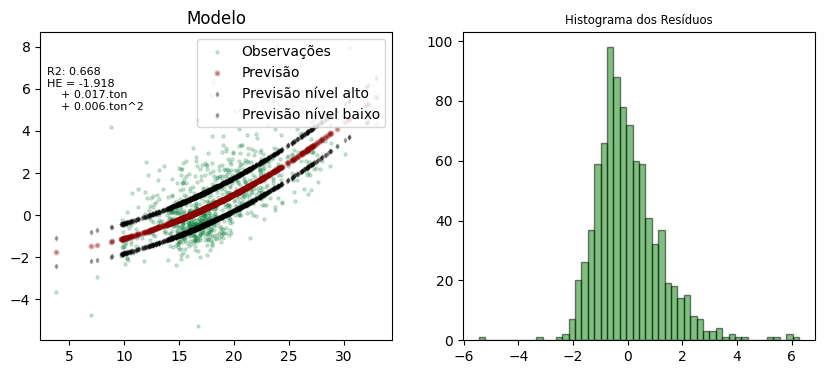

In [113]:
# Procurando encontrar uma equação que entregue melhor correlação, uma equação polinomial de segunda ordem foi elaborada 
# utilizando a mesma metodologia dos mínimos quadrados ordinários 
# modelo de previsão quadrático 
X = dias_p["ton"]
X2 = dias_p["ton"]**2
y = dias_p["horas_extras"]
x0 = np.ones(len(dias_p["ton"]))
x0 = pd.DataFrame(x0, columns = ["x0"])
X = pd.concat([x0, X, X2], axis = 1)

coefs = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
prev = X.dot(coefs)

dados = dias_p[["ton", "horas_extras"]].copy()
dados["prev"] = prev
dados["res"] = dados["horas_extras"]-dados["prev"]
dados["res^2"] = dados["res"]**2

var = (1/(len(dias_p)-1))*dados["res^2"].sum()
var_coefs = var * (np.linalg.inv(X.T.dot(X)))
var_coefs = np.diag(pd.DataFrame(var_coefs))

t = sc.stats.t.ppf(0.975,len(dias_p)-1)
IC_coefs = t * var_coefs
corr = np.corrcoef(dados["horas_extras"], dados["prev"])[0][1]
prev_nb = prev = X.dot(coefs - IC_coefs)
prev_na = prev = X.dot(coefs + IC_coefs)
dados["prev_nb"] = prev_nb
dados["prev_na"] = prev_na

figura2, axis = plt.subplots(1,2,figsize = (10,4))
axis[0].scatter(dados["ton"], dados["horas_extras"], alpha = 0.2, edgecolors = "g", s = 5, label = "Observações")
axis[0].scatter(dados["ton"], dados["prev"], alpha = 0.3, color = "darkred",  linewidth = 2, s = 5, label = "Previsão")
axis[0].scatter(dados["ton"], dados["prev_nb"], alpha = 0.3, color = "black", marker = "d", s = 5,label = "Previsão nível alto")
axis[0].scatter(dados["ton"], dados["prev_na"], alpha = 0.3, color = "black",   marker = "d", s = 5,label = "Previsão nível baixo")
axis[0].text(3, 5, f"R2: {round(corr, 3)}\nHE = {round(coefs[0],3)}\n    + {round(coefs[1],3)}.ton\n    + {round(coefs[2],3)}.ton^2", fontsize = 8)
axis[0].set_title("Modelo")
axis[0].legend(loc = "upper right")

axis[1].hist(x = dados["res"], bins = 50, alpha = 0.5,color = "g", edgecolor = "black")
axis[1].set_title("Histograma dos Resíduos", fontsize = "smaller")
plt.show()



In [114]:
def he_prev2(X, coefs, IC):
    he_p = coefs[0] + coefs[1]*X + coefs[2]*X*X
    he_p_nivelb = (coefs[0]-IC[0]) + (coefs[1]-IC[1])*X + (coefs[2]-IC[2])*X*X
    he_p_nivela = (coefs[0]+IC[0]) + (coefs[1]+IC[1])*X + (coefs[2]+IC[2])*X*X

    resultados = pd.DataFrame({"r_med": he_p, "r_nivel_baixo": he_p_nivelb, "r_nivel_alto": he_p_nivela})

    return(resultados)

teste = he_prev2(tonelagem1, coefs, IC_coefs)

In [115]:
# montagem da tabela com as tonelagens, horas extras atuais e horas extras previstas para cada setor 
previsao2 = pd.concat([tonelagem1, teste], axis = 1)
previsao2.index = range(1,22)
previsao2["ton_a"] = tonelagem
previsao2["horas_e_a"] = dias_p.groupby("Setor")["horas_extras"].mean()
previsao2

,ton,r_med,r_nivel_baixo,r_nivel_alto,ton_a,horas_e_a
1,17.286667,0.291782,-0.471605,1.055169,17.708780,-0.376902
2,17.171667,0.264390,-0.498162,1.026942,15.425122,0.327163
3,17.769667,0.408686,-0.358211,1.175583,18.955128,-0.611632
4,17.619333,0.371978,-0.393826,1.137783,15.006410,0.296487
5,17.431379,0.326493,-0.437945,1.090932,15.735385,-0.804368
6,17.541000,0.352966,-0.412268,1.118201,16.377317,-0.198041
7,17.051724,0.236002,-0.525679,0.997682,17.419487,-0.248812
8,19.267667,0.790331,0.012534,1.568127,19.459268,1.952366
9,19.101379,0.746542,-0.030043,1.523128,21.710500,1.279917
10,19.275333,0.792358,0.014506,1.570210,21.242683,0.978382


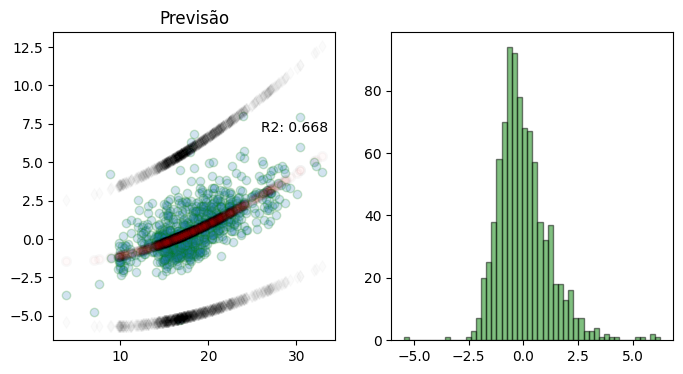

In [109]:
# modelo cúbico 
X = dias_p["ton"]
X2 = dias_p["ton"]**2
X3 = dias_p["ton"]**3
y = dias_p["horas_extras"]
x0 = np.ones(len(dias_p["ton"]))
x0 = pd.DataFrame(x0, columns = ["x0"])
X = pd.concat([x0, X, X2, X3], axis = 1)

coefs = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
prev = X.dot(coefs)

dados = dias_p[["ton", "horas_extras"]].copy()
dados["prev"] = prev
dados["res"] = dados["horas_extras"]-dados["prev"]
dados["res^2"] = dados["res"]**2

var = (1/(len(dias_p)-1))*dados["res^2"].sum()
var_coefs = var * (np.linalg.inv(X.T.dot(X)))
var_coefs = np.diag(pd.DataFrame(var_coefs))

t = sc.stats.t.ppf(0.975,len(dias_p)-1)
IC_coefs = t * var_coefs
corr = np.corrcoef(dados["horas_extras"], dados["prev"])[0][1]
prev_nb = prev = X.dot(coefs - IC_coefs)
prev_na = prev = X.dot(coefs + IC_coefs)
dados["prev_nb"] = prev_nb
dados["prev_na"] = prev_na

figura3, axis = plt.subplots(1,2,figsize = (8,4))
axis[0].scatter(dados["ton"], dados["horas_extras"], alpha = 0.2, edgecolors = "g")
axis[0].scatter(dados["ton"], dados["prev"], alpha = 0.025, color = "r", edgecolors = "black", linewidth = 2)
axis[0].scatter(dados["ton"], dados["prev_nb"], alpha = 0.015, color = "black", edgecolors = "black", linewidth = 1, marker = "d")
axis[0].scatter(dados["ton"], dados["prev_na"], alpha = 0.015, color = "black", edgecolors = "black", linewidth = 1, marker = "d")
axis[0].text(26, 7, f"R2: {round(corr, 3)}")
axis[0].set_title("Previsão")


axis[1].hist(x = dados["res"], bins = 50, alpha = 0.5,color = "g", edgecolor = "black")
plt.show()


In [21]:
def he_prev3(X, coefs, IC):
    he_p = coefs[0] + coefs[1]*X + coefs[2]*X*X + coefs[2]*X*X*X
    he_p_nivelb = (coefs[0]-IC[0]) + (coefs[1]-IC[1])*X + (coefs[2]-IC[2])*X*X + (coefs[2]-IC[2])*X*X*X
    he_p_nivela = (coefs[0]+IC[0]) + (coefs[1]+IC[1])*X + (coefs[2]+IC[2])*X*X + (coefs[2]-IC[2])*X*X*X

    resultados = pd.DataFrame({"r_med": he_p, "r_nivel_baixo": he_p_nivelb, "r_nivel_alto": he_p_nivela})

    return(resultados)

teste = he_prev2(tonelagem1, coefs, IC_coefs)

In [ ]:
# montagem da tabela com as tonelagens, horas extras atuais e horas extras previstas para cada setor 
previsao3 = pd.concat([tonelagem1, teste], axis = 1)
previsao3.index = range(1,22)
previsao3["ton_a"] = tonelagem
previsao3["horas_e_a"] = dias_p.groupby("Setor")["horas_extras"].mean()
previsao3

,ton,r_med,r_nivel_baixo,r_nivel_alto,ton_a,horas_e_a
1,17.286667,0.894586,-4.478542,6.267714,17.708780,-0.376902
2,17.171667,0.854453,-4.506166,6.215072,15.425122,0.327163
3,17.769667,1.066944,-4.358803,6.492690,18.955128,-0.611632
4,17.619333,1.012639,-4.396715,6.421994,15.006410,0.296487
5,17.431379,0.945582,-4.443297,6.334461,15.735385,-0.804368
6,17.541000,0.984579,-4.416239,6.385398,16.377317,-0.198041
7,17.051724,0.812967,-4.534614,6.160548,17.419487,-0.248812
8,19.267667,1.640550,-3.949247,7.230347,19.459268,1.952366
9,19.101379,1.573963,-3.997560,7.145485,21.710500,1.279917
10,19.275333,1.643638,-3.947002,7.234278,21.242683,0.978382


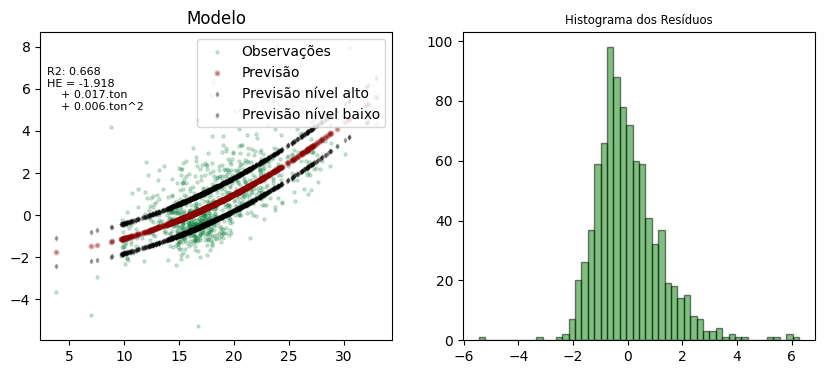

In [116]:
# como o modelo quadrático entregou resultados mais condizentes com as observações, esse modelo deve ser apresentado como previsão 
# vale ressalvar que a variabilidade do modelo é alta
# muitas variáveis não manipuláveis interferem nas observações utilizadas para o modelo de regressão 
# QUAL MOTORISTA ESTÁ DIRIGINDO ?
# A EQUIPE DE COLETORES É PRODUTIVA ?
# A CAPACIDADE DE CARGA DOS CAMINHÕES VARIA 
# A TOPOGRAFIA DOS SETORES VARIA (RUAS SEM SAÍDA, SUBIDAS, SEMÁFOROS, RUAS INTERDITADAS....)
# EVENTOS INESPERADOS (QUEBRAS DE CAMINHÕES, COLETORES MACHUCADOS, SINISTROS...)
# esses fatores interferem na produtividade dos setores, logo, também interferem na geração de goras extras 
figura2

In [124]:
with pd.ExcelWriter("resultados.xlsx") as writer:
    previsao.to_excel(writer, sheet_name = "previsao1")
    previsao2.to_excel(writer, sheet_name = "previsao2")
    previsao3.to_excel(writer, sheet_name = "previsao3")

In [123]:
resultados

NameError: name 'resultados' is not defined